# Video aula
https://github.com/nightfury217836/Bank-Fraud-Prediction

https://www.youtube.com/watch?v=7lPNOP4dFN0

In [3]:
import pandas as pd

df = pd.read_csv('Fraud.csv')

In [4]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [6]:
df.isnull().any() #verificando se há valores nulos

step              False
type              False
amount            False
nameOrig          False
oldbalanceOrg     False
newbalanceOrig    False
nameDest          False
oldbalanceDest    False
newbalanceDest    False
isFraud           False
isFlaggedFraud    False
dtype: bool

In [7]:
import warnings
warnings.filterwarnings('ignore')
import os
from IPython.display import display

#data processing
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#modeling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve, average_precision_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

try:
    import xgboost as xgb
except:
    xgb = None

import joblib
print('Setup complete.')



Setup complete.


In [8]:
DATA_PATH = 'Fraud.csv'
assert os.path.exists(DATA_PATH), f"Data file not found at {DATA_PATH}"

In [9]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


## EDA

In [10]:
df.shape

(6362620, 11)

In [11]:
df.dtypes

step                int64
type               object
amount            float64
nameOrig           object
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object

In [12]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [13]:
df['isFraud'].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [14]:
print("Fraud ratio: {:.4f}%".format(df['isFraud'].mean() * 100))

Fraud ratio: 0.1291%


## Fraud Rate

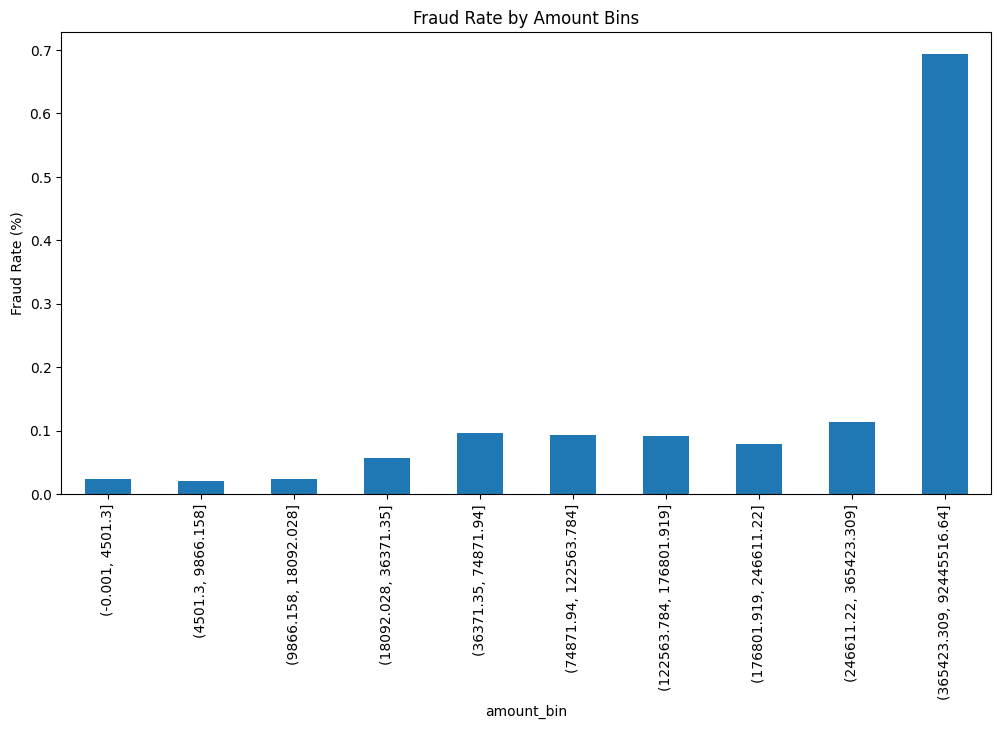

In [15]:
df['amount_bin'] = pd.qcut(df['amount'], 10, duplicates='drop') #criando bins para a coluna 'amount' usando quantis

fraud_rate = df.groupby('amount_bin')['isFraud'].mean() #calculando a taxa de fraude para cada bin
fraud_rate *= 100

plt.figure(figsize=(12, 6))
fraud_rate.plot(kind='bar')
plt.ylabel('Fraud Rate (%)')
plt.title('Fraud Rate by Amount Bins')
plt.show()

# Checking missing data

In [16]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
amount_bin        0
dtype: int64

Conforme o dataset

oldbalanceDest - initial balance recipient before the transaction. Note that there is not information for customers that start with M (Merchants).

newbalanceDest - new balance recipient after the transaction. Note that there is not information for customers that start with M (Merchants).

In [17]:
merchant_txns = df[df['nameDest'].str.startswith('M')]
merchant_txns[['oldbalanceDest', 'newbalanceDest']].describe()

,oldbalanceDest,newbalanceDest
count,2151495.0,2151495.0
mean,0.0,0.0
std,0.0,0.0
min,0.0,0.0
25%,0.0,0.0
50%,0.0,0.0
75%,0.0,0.0
max,0.0,0.0


Sem dados faltantes

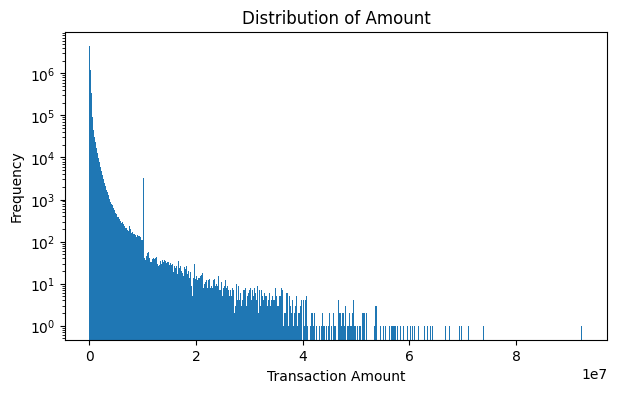

In [18]:
#outliers

df['amount'].describe()

#Visualizando a distribuição dos valores de 'amount'
plt.figure(figsize=(7, 4))
plt.hist(df['amount'], bins=500)
plt.yscale('log') #usando escala logarítmica para melhor visualização
plt.xlabel('Transaction Amount')
plt.ylabel('Frequency')
plt.title('Distribution of Amount')
plt.show()

In [19]:
df['log_amount'] = np.log1p(df['amount']) #criando nova coluna com o log do valor da transação

p99 = df['amount'].quantile(0.99) #calculando o percentil 99 para identificar outliers
df['is_high_amount'] = (df['amount'] > p99).astype(int) #criando coluna indicando se a transação é um outlier

df['is_high_amount'].value_counts()

is_high_amount
0    6298993
1      63627
Name: count, dtype: int64

In [20]:
total_txns = len(df)
fraud_txns = df['isFraud'].sum()

print(f"Total transactions: {total_txns:,}")
print(f"Fraud transactions: {fraud_txns:,}")

fraud_rate = (fraud_txns / total_txns) * 100
print(f"Fraud ratio: {fraud_rate:.4f}%")

fraud_pct = (df['isFlaggedFraud'].sum() / total_txns) * 100
print(f"Flagged as fraud ratio: {fraud_pct:.4f}%")

Total transactions: 6,362,620
Fraud transactions: 8,213
Fraud ratio: 0.1291%
Flagged as fraud ratio: 0.0003%


Ou seja, o método não está pegando bem as transições fraudulentas, estamos capturando bem menos que 0,13%

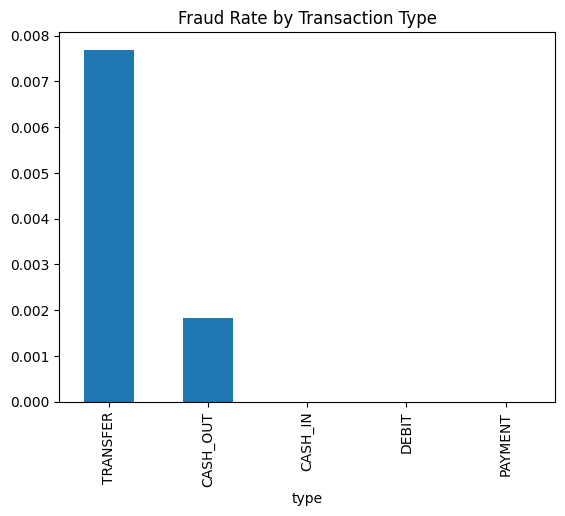

In [21]:
df.groupby('type')['isFraud'].mean().sort_values(ascending=False).plot(kind='bar')
plt.title('Fraud Rate by Transaction Type')
plt.show()

In [22]:
#Analise com o tempo

df['hour'] = (df['step'] % 24).astype(int) #criando coluna com a hora do dia

hourly_stat = (
    df.groupby('hour')
    .agg(
        total_transactions = ('isFraud', 'count'),
        fraud_transactions = ('isFraud', 'sum'),
        fraud_rate = ('isFraud', 'mean')
    )
    .reset_index()
)

display(hourly_stat.head())

,hour,total_transactions,fraud_transactions,fraud_rate
0,0,71587,300,0.004191
1,1,27111,358,0.013205
2,2,9018,372,0.041251
3,3,2007,326,0.162431
4,4,1241,274,0.220790


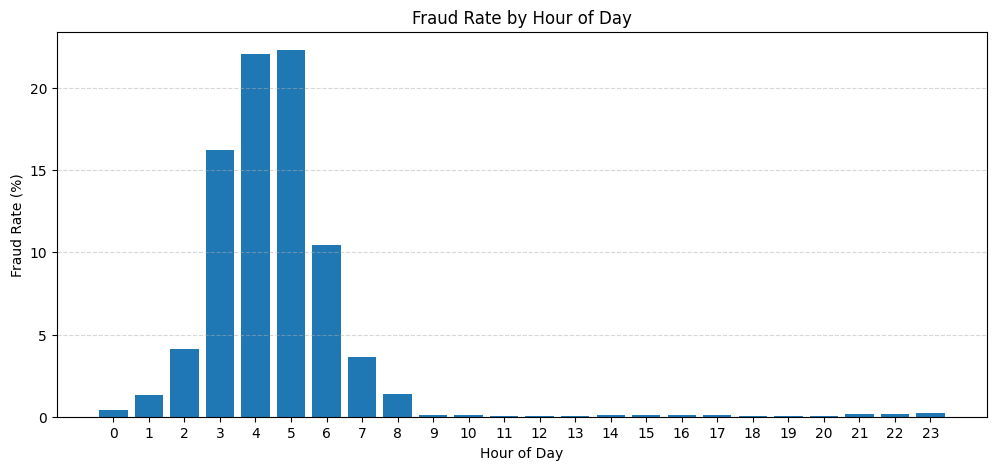

In [23]:
#fraud rate por hora
plt.figure(figsize=(12, 5)) 

plt.bar(hourly_stat['hour'], hourly_stat['fraud_rate'] * 100)
plt.xlabel('Hour of Day')
plt.ylabel('Fraud Rate (%)')
plt.title('Fraud Rate by Hour of Day')
plt.xticks(range(0, 24))
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

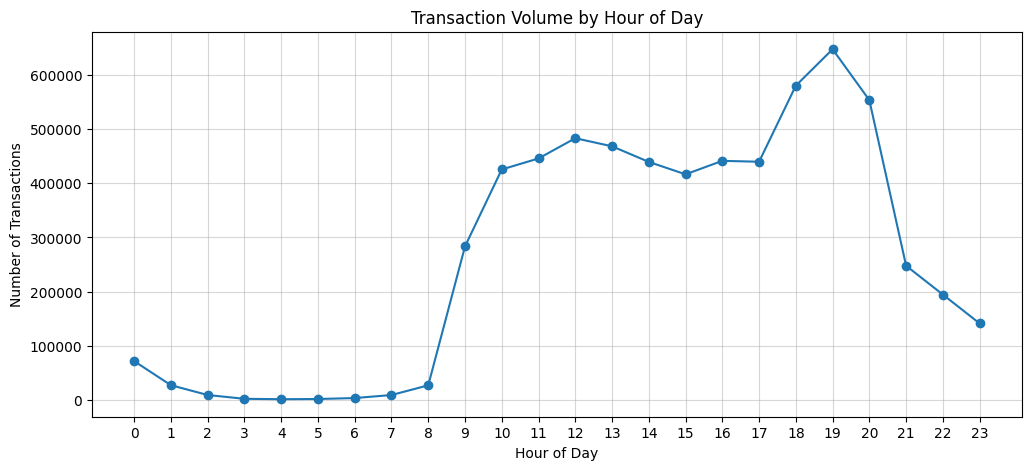

In [24]:
plt.figure(figsize=(12, 5)) 

plt.plot(hourly_stat['hour'], hourly_stat['total_transactions'], 'o-')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Transactions')
plt.title('Transaction Volume by Hour of Day')
plt.xticks(range(0, 24))
plt.grid(alpha=0.5)
plt.show()

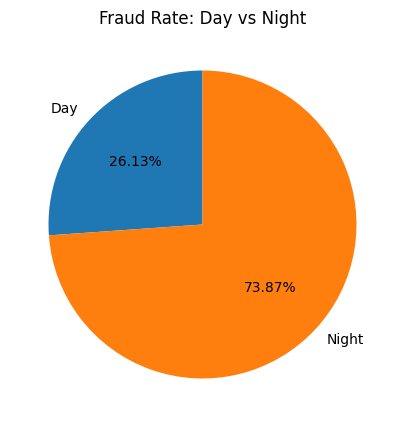

In [25]:
#Day vs Night Fraud Analysis

plt.figure(figsize=(12, 5))

df['is_night'] = df['hour'].apply(lambda x: 1 if (x >= 0 and x < 6) or (x >= 20 and x < 24) else 0)

day_night_fraud = (
    df.groupby('is_night')['isFraud']
    .mean() 
    .rename({0: 'Day', 1: 'Night'})
)

day_night_fraud.plot(
    kind='pie',
    autopct='%1.2f%%',
    startangle=90,
    legend=False
)

plt.ylabel('')
plt.title('Fraud Rate: Day vs Night')
plt.show()

## Correlation check

Text(0.5, 1.0, 'Correlation Heatmap')

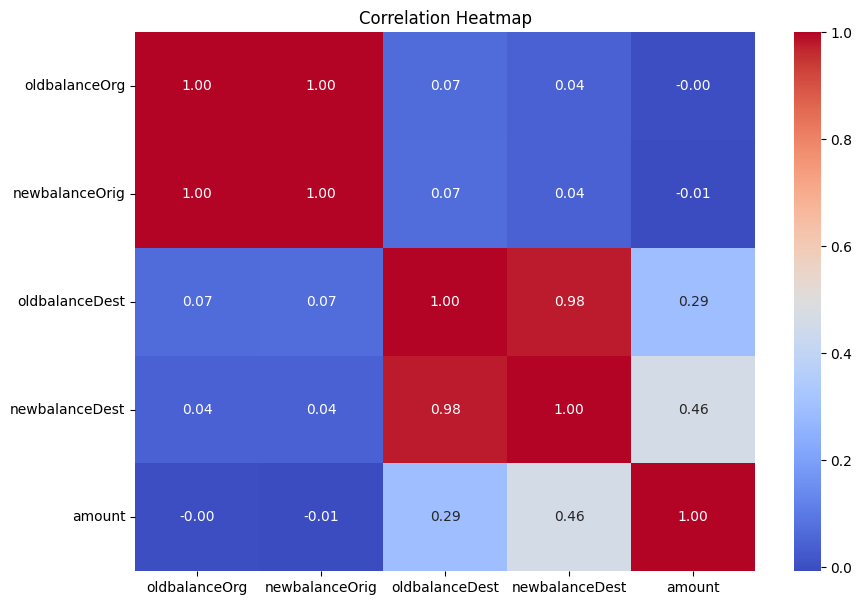

In [26]:
plt.figure(figsize=(10, 7))

corr = df[['oldbalanceOrg','newbalanceOrig',
           'oldbalanceDest','newbalanceDest',
           'amount']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')

A matriz de correlação está indicando severas multilinearidades entre os balanços de pre e pos transação

# Feature Engineering and Data Cleaning

In [27]:
#Feature Engineering - Balances e diferenças

df['balance_diff_orig'] = df['oldbalanceOrg'] - df['newbalanceOrig']
df['balance_diff_dest'] = df['oldbalanceDest'] - df['newbalanceDest'] 

#Feature Reduction
df = df.drop(columns=[
    'oldbalanceOrg', 'newbalanceOrig',
    'oldbalanceDest', 'newbalanceDest'
])

In [28]:
df.drop(columns=['amount_bin'], inplace=True)
df.fillna(0, inplace=True)

le = LabelEncoder()
df['type_enc'] = le.fit_transform(df['type']) #criando coluna com a codificação numérica do tipo de transação

df.drop(['nameOrig', 'nameDest', 'type'], axis=1, inplace=True)

## Train Test Split

In [29]:
X = df.drop(columns=['isFraud', 'isFlaggedFraud'])
y = df['isFraud'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = RobustScaler() #usando RobustScaler para lidar melhor com outliers
num_cols = X_train.select_dtypes(include=[np.number]).columns #selecionando apenas as colunas numéricas para escalonamento
scaler.fit(X_train[num_cols]) #ajustando o scaler apenas nos dados de treino

X_train[num_cols] = scaler.transform(X_train[num_cols]) #transformando os dados de treino
X_test[num_cols] = scaler.transform(X_test[num_cols]) #transformando os dados de teste usando o mesmo scaler ajustado nos dados de treino

## Model training and evaluation

In [28]:
models = { } 

#Logistic Regression
print("Treinando Logistic Regression...")
lr = LogisticRegression(max_iter=300,
                        solver='lbfgs',
                        class_weight='balanced', #usando class_weight para lidar com o desbalanceamento
                        n_jobs=-1
) 

lr.fit(X_train, y_train)
models['Logistic Regression'] = lr
print("Logistic Regression treinado.")

#Random Forest
print("Treinando Random Forest...")
rf = RandomForestClassifier(
    n_estimators=50,
    max_depth=12,
   min_samples_leaf=100,
   class_weight='balanced', #usando class_weight para lidar com o desbalanceamento
   n_jobs=-1,
    random_state=42
)
rf.fit(X_train, y_train)
models['Random Forest'] = rf
print("Random Forest treinado.")

# XGBoost
# if xgb is not None:
#     print("Treinando XGBoost...")
#     scale_pos = (y_train == 0).sum() / (y_train == 1).sum() #calculando o scale_pos_weight com base na proporção das classes
#     xgb_clf = xgb.XGBClassifier(
#         n_estimators=100,
#         max_depth=6,
#         learning_rate=0.1,
#         subsample=0.8,
#         colsample_bytree=0.8,
#         scale_pos_weight=scale_pos, #ajustando o scale_pos_weight para lidar com o desbalanceamento
#         use_label_encoder=False,
#         eval_metric='logloss',
#         tree_method='hist',
#         n_jobs=-1,
#     )
#     xgb_clf.fit(X_train, y_train)
#     models['XGBoost'] = xgb_clf
#     print("XGBoost treinado.")
# else:
#     print("XGBoost não está instalado. Pulando treinamento do XGBoost.")

Treinando Logistic Regression...
Logistic Regression treinado.
Treinando Random Forest...
Random Forest treinado.


In [29]:
results = []

for name, model in models.items():
    if hasattr(model, 'predict_proba'): #verificando se o modelo tem o método predict_proba para calcular as probabilidades de fraude
        scores = model.predict_proba(X_test)[:, 1] #obtendo as probabilidades de fraude (classe positiva)
    else:
        scores = model.decision_function(X_test) #usando decision_function para modelos que não possuem predict_proba
    print('\n', name)
    print(classification_report(y_test, (scores>0.8).astype(int)))
    results.append({
        'model': name,
        'roc_auc': roc_auc_score(y_test, scores), #calculando a métrica ROC AUC para avaliar o desempenho do modelo
        'aucprc': average_precision_score(y_test, scores) #calculando a métrica AUC-PRC para avaliar o desempenho do modelo em dados desbalanceados
    })
    #ROC AUC é uma métrica que avalia a capacidade do modelo de distinguir entre as classes positiva e negativa, 
    # enquanto AUC-PRC é especialmente útil para avaliar o desempenho em conjuntos de dados desbalanceados, focando na precisão e recall da classe positiva (fraude).

pd.DataFrame(results).sort_values(by='aucprc', ascending=False)


 Logistic Regression
              precision    recall  f1-score   support

           0       1.00      0.98      0.99   1270881
           1       0.06      0.80      0.12      1643

    accuracy                           0.98   1272524
   macro avg       0.53      0.89      0.56   1272524
weighted avg       1.00      0.98      0.99   1272524


 Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.36      0.89      0.51      1643

    accuracy                           1.00   1272524
   macro avg       0.68      0.94      0.75   1272524
weighted avg       1.00      1.00      1.00   1272524



,model,roc_auc,aucprc
1,Random Forest,0.997604,0.839102
0,Logistic Regression,0.977742,0.549335


O foco não está na acurácia, está em: 

- recall: capacidade de capturar a fraude. random forest captura 96%, e regressão 89%

- precision: falso positivo para fraudes. 0.06 em RF e 0.03 em LR. Ou seja, em RF está tendo muitos falsos-positivos/alarmes



UPRC (Area Under the Precision-Recall Curve): Em dados desequilibrados, essa é a métrica de ouro. Ela resume o equilíbrio entre capturar a fraude e não irritar o cliente bom.

O Random Forest (0.84) humilha a Regressão Logística (0.54).

Isso indica que o modelo é muito "sensível". Ele está pegando quase todas as fraudes, mas está bloqueando muita gente inocente no caminho. Na prática bancária, isso gera um volume imenso de chamados no suporte de clientes reclamando que o cartão não passou

# Tuning threshold

In [30]:
# rf_tuned = RandomForestClassifier(
#     n_estimators=100,
#     max_depth=10,
#     min_samples_leaf=200, #impacto na precisão
#     min_samples_split=500, #adicionando min_samples_split para reduzir ainda mais o overfitting
#     class_weight='balanced',
#     n_jobs=-1,
#     random_state=42
# )

# rf_tuned.fit(X_train, y_train)

In [31]:
from sklearn.ensemble import IsolationForest

In [32]:
df.head()

,step,amount,isFraud,isFlaggedFraud,log_amount,is_high_amount,hour,is_night,balance_diff_orig,balance_diff_dest,type_enc
0,1,9839.64,0,0,9.194276,0,1,1,9839.64,0.0,3
1,1,1864.28,0,0,7.531166,0,1,1,1864.28,0.0,3
2,1,181.00,1,0,5.204007,0,1,1,181.00,0.0,4
3,1,181.00,1,0,5.204007,0,1,1,181.00,21182.0,1
4,1,11668.14,0,0,9.364703,0,1,1,11668.14,0.0,3


In [33]:
fraudes = df[df['isFraud'] == 1]
normal = df[df['isFraud'] == 0]

outlier_fraction = len(fraudes) / len(normal) #calculando a fração de outliers com base na proporção de transações fraudulentas em relação às normais

In [34]:
print(f"Outlier Fraction: {outlier_fraction:.6f}")

Outlier Fraction: 0.001292


In [35]:
IF_tuned =  IsolationForest(n_estimators=100, max_samples=len(X),
                                        contamination=outlier_fraction, random_state=42, verbose=0)

In [36]:
IF_tuned.fit(X)
scores_pred = IF_tuned.decision_function(X)
y_pred = IF_tuned.predict(X)

In [37]:
print(np.unique(y_pred, return_counts=True))

(array([-1,  1]), array([   8224, 6354396]))


In [38]:
y_pred[y_pred == -1] = 1
y_pred[y_pred == 1] = 0

In [39]:
n_errors = (y_pred != y).sum()

print(f"Isolation Forest - Número de erros: {n_errors}")

Isolation Forest - Número de erros: 8213


In [40]:
n_fraudes = (y_pred == 1).sum()
print(f"Número de fraudes detectadas: {n_fraudes}")
print(f"Numero de fraudes reais: {y.sum()}")

Número de fraudes detectadas: 0
Numero de fraudes reais: 8213


In [41]:
# models['Random Forest Tuned'] = rf_tuned
# models['Random Forest'] = rf
models['Isolation Forest'] = IF_tuned

In [42]:
results = []

for name, model in models.items():
    if hasattr(model, 'predict_proba'): #verificando se o modelo tem o método predict_proba para calcular as probabilidades de fraude
        scores = model.predict_proba(X_test)[:, 1] #obtendo as probabilidades de fraude (classe positiva)
    else:
        scores = model.decision_function(X_test) #usando decision_function para modelos que não possuem predict_proba
    print('\n', name)
    print(classification_report(y_test, (scores>0.83).astype(int))) #scores>numero é um threshold que considera qual probabilidade de fraude é alta o suficiente para classificar como fraude
    results.append({
        'model': name,
        'roc_auc': roc_auc_score(y_test, scores), #calculando a métrica ROC AUC para avaliar o desempenho do modelo
        'aucprc': average_precision_score(y_test, scores) #calculando a métrica AUC-PRC para avaliar o desempenho do modelo em dados desbalanceados
    })
    #ROC AUC é uma métrica que avalia a capacidade do modelo de distinguir entre as classes positiva e negativa, 
    # enquanto AUC-PRC é especialmente útil para avaliar o desempenho em conjuntos de dados desbalanceados, focando na precisão e recall da classe positiva (fraude).

pd.DataFrame(results).sort_values(by='aucprc', ascending=False)


 Logistic Regression
              precision    recall  f1-score   support

           0       1.00      0.99      0.99   1270881
           1       0.07      0.79      0.13      1643

    accuracy                           0.99   1272524
   macro avg       0.54      0.89      0.56   1272524
weighted avg       1.00      0.99      0.99   1272524


 Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.41      0.88      0.56      1643

    accuracy                           1.00   1272524
   macro avg       0.70      0.94      0.78   1272524
weighted avg       1.00      1.00      1.00   1272524


 Isolation Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.00      0.00      0.00      1643

    accuracy                           1.00   1272524
   macro avg       0.50      0.50      0.50   1272524
weighted avg     

,model,roc_auc,aucprc
1,Random Forest,0.997604,0.839102
0,Logistic Regression,0.977742,0.549335
2,Isolation Forest,0.558101,0.002792


In [43]:
from sklearn.metrics import classification_report, accuracy_score

In [44]:
print("Accuracy Score :")
print(accuracy_score(y, y_pred))
print("Classification Report :")
print(classification_report(y, y_pred))

Accuracy Score :
0.9987091795518198
Classification Report :
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   6354407
           1       0.00      0.00      0.00      8213

    accuracy                           1.00   6362620
   macro avg       0.50      0.50      0.50   6362620
weighted avg       1.00      1.00      1.00   6362620



In [45]:
import numpy as np
from sklearn.metrics import classification_report

# 1. Obter as probabilidades do Random Forest
rf_probs = rf.predict_proba(X_test)[:, 1]

# 2. Criar um array para armazenar as decisões finais (começa tudo como zero/legítimo)
final_preds = np.zeros_like(rf_probs)

# 3. Identificar os casos para cada estágio da cascata
idx_bloqueio_direto = rf_probs > 0.80
idx_duvida = (rf_probs >= 0.50) & (rf_probs <= 0.80)

# 4. Decisão 1: Bloqueio Direto pelo Random Forest
final_preds[idx_bloqueio_direto] = 1

# 5. Decisão 2: Desempate com Isolation Forest na Zona de Dúvida
if np.any(idx_duvida):
    # # Pedimos ao IF para analisar apenas os dados da zona de dúvida
    # if_preds_duvida = IF_tuned.predict(X_test[idx_duvida])
    
    # # Converter IF (-1 é anomalia) para 0 e 1
    # # Se o IF disser que é anomalia (-1), marcamos como fraude (1)
    # final_preds[idx_duvida] = (if_preds_duvida == -1).astype(int)

    # Em vez de if_preds = iso_forest.predict(X_test[idx_duvida])
    # Use o score de anomalia:
    if_scores = IF_tuned.decision_function(X_test[idx_duvida])

    # Só marque como fraude se o score for MUITO baixo (muito anômalo)
    # Geralmente scores abaixo de -0.1 ou -0.2 indicam anomalias fortes
    final_preds[idx_duvida] = (if_scores < -0.1).astype(int)

# 6. Avaliação Final
print("Resultado da Detecção em Cascata (RF + IF):")
print(classification_report(y_test, final_preds))

Resultado da Detecção em Cascata (RF + IF):
              precision    recall  f1-score   support

           0       1.00      0.98      0.99   1270881
           1       0.06      0.96      0.12      1643

    accuracy                           0.98   1272524
   macro avg       0.53      0.97      0.55   1272524
weighted avg       1.00      0.98      0.99   1272524



In [46]:
random_forest_thresholds = []

print("Resultado da Detecção em Random Forest score 0.7:")
scores = rf.predict_proba(X_test)[:, 1]
random_forest_thresholds.append({
        'model': 'random_forest_0.7',
        'roc_auc': roc_auc_score(y_test, scores), #calculando a métrica ROC AUC para avaliar o desempenho do modelo
        'aucprc': average_precision_score(y_test, scores) #calculando a métrica AUC-PRC para avaliar o desempenho do modelo em dados desbalanceados
    })
print(classification_report(y_test, (scores>0.7).astype(int)))

print("Resultado da Detecção em Random Forest score 0.8:")
scores = rf.predict_proba(X_test)[:, 1]
random_forest_thresholds.append({
        'model': 'random_forest_0.8',
        'roc_auc': roc_auc_score(y_test, scores), #calculando a métrica ROC AUC para avaliar o desempenho do modelo
        'aucprc': average_precision_score(y_test, scores) #calculando a métrica AUC-PRC para avaliar o desempenho do modelo em dados desbalanceados
    })
print(classification_report(y_test, (scores>0.8).astype(int)))

print("Resultado da Detecção em Random Forest score 0.9:")
scores = rf.predict_proba(X_test)[:, 1]
random_forest_thresholds.append({
        'model': 'random_forest_0.9',
        'roc_auc': roc_auc_score(y_test, scores), #calculando a métrica ROC AUC para avaliar o desempenho do modelo
        'aucprc': average_precision_score(y_test, scores) #calculando a métrica AUC-PRC para avaliar o desempenho do modelo em dados desbalanceados
    })

print(classification_report(y_test, (scores>0.9).astype(int)))
pd.DataFrame(random_forest_thresholds).sort_values(by='aucprc', ascending=False)

Resultado da Detecção em Random Forest score 0.7:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.20      0.91      0.33      1643

    accuracy                           1.00   1272524
   macro avg       0.60      0.95      0.66   1272524
weighted avg       1.00      1.00      1.00   1272524

Resultado da Detecção em Random Forest score 0.8:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.36      0.89      0.51      1643

    accuracy                           1.00   1272524
   macro avg       0.68      0.94      0.75   1272524
weighted avg       1.00      1.00      1.00   1272524

Resultado da Detecção em Random Forest score 0.9:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.61      0.83      0.70      1643

    accuracy                    

,model,roc_auc,aucprc
0,random_forest_0.7,0.997604,0.839102
1,random_forest_0.8,0.997604,0.839102
2,random_forest_0.9,0.997604,0.839102


Resumindo, roc_auc e aucprc é independente do score utilizado nos teste, se no classification_report o Modelo B parecer melhor (é provavel que a escolha do threshold fou pura sorte para ele), mas o AUCPRC do Modelo B é menor que o do Modelo A, o AUCPRC anuncia que: "Ei, o Modelo A é tecnicamente superior. Se ajustar o threshold dele corretamente, ele vai esmagar o Modelo B".

Portanto, usar Isolation Forest para esses dados, tanto como critério solo como quanto critério de desempate é péssimo, pois indica precisão de 0.06, ou seja, está gerando 94% de falsos positivos, por mais que esteja acertando 96% das fraudes. Manter somente o critério de Random Forest é melhor, pois atinge uma precisão alta com um recall alto já para os scores 0.7, 0.8 e 0.9

Note ainda que o F1-SCORE é o melhor em score>0.9, com f1-score=0.7, existe um equilibrio bom entre os falsos-positivos (39%), e a fraudes que passaram (17%)

### Cenário A: O Ideal Técnico (F1-Score)
Se você quer o modelo estatisticamente mais robusto, o Threshold 0.9 é o vencedor disparado. Um F1-Score de 0.70 em dados tão desbalanceados é um resultado de "nível mundial". Você tem uma precisão altíssima (0.61) e ainda mantém um Recall muito sólido (0.83).

### Cenário B: O Ideal de Segurança (Conservador)
Se o prejuízo por cada fraude for absurdamente alto (ex: transferências de R$ 50.000,00) e o custo de ligar para o cliente para confirmar for baixo, o Threshold 0.7 pode ser melhor, pois ele garante que 91% das fraudes sejam detectadas.

### Cenário C: O Ideal de Experiência do Usuário (UX)
Se o seu banco quer ser conhecido por "nunca bloquear o cartão por engano", o Threshold 0.9 é o único caminho. Com 0.61 de precisão, a maioria dos seus alertas são reais, evitando que clientes fiquem passando vergonha na fila do mercado com o cartão negado.

## Salvando o melhor ajuste de modelo

In [47]:
from sklearn.metrics import precision_recall_curve

model = models['Random Forest'] #selecionando o modelo Random Forest para análise da curva de precisão-recall

y_scores = model.predict_proba(X_test)[:, 1] #obtendo as probabilidades de fraude para o conjunto de teste
precision, recall, thresholds = precision_recall_curve(y_test, y_scores) #calculando os valores de precisão, recall e os limiares para a curva de precisão-recall

#Achando o melhor threshold com recall >= 0.9 e melhor precisão
candidates = [
    (p, r, t) for p, r, t in zip(precision[:-1], recall[:-1], thresholds) 
    if r >= 0.9
]

best_threshold, best_recall, best_precision = max(candidates, key=lambda x: x[0]) #selecionando o threshold com a maior precisão entre os candidatos que têm recall >= 0.9
print(f"Best Threshold: {best_threshold:.4f}")
print(f"Precision: {best_precision:.4f}, Recall: {best_recall:.4f}")

Best Threshold: 0.2487
Precision: 0.7364, Recall: 0.9002


In [48]:
from sklearn.metrics import roc_auc_score, average_precision_score

def evaluate_model(model, X, y):
    score = model.predict_proba(X)[:, 1] #obtendo as probabilidades de fraude para o conjunto de teste
    return{
        "ROC-AUC": roc_auc_score(y, score), #calculando a métrica ROC AUC para avaliar o desempenho do modelo
        "PR-AUC": average_precision_score(y, score) #calculando a métrica AUC-PRC para avaliar o desempenho do modelo em dados desbalanceados
    }

print("Avaliação do modelo Random Forest Tunado:", evaluate_model(rf, X_test, y_test))

Avaliação do modelo Random Forest Tunado: {'ROC-AUC': 0.9976043274475312, 'PR-AUC': 0.8391015089145742}


In [49]:
results = []

for name, model in models.items():
    if hasattr(model, 'predict_proba'): #verificando se o modelo tem o método predict_proba para calcular as probabilidades de fraude
        scores = model.predict_proba(X_test)[:, 1] #obtendo as probabilidades de fraude (classe positiva)
    else:
        scores = model.decision_function(X_test) #usando decision_function para modelos que não possuem predict_proba
    print('\n', name)
    print(classification_report(y_test, (scores>0.83).astype(int))) #scores>numero é um threshold que considera qual probabilidade de fraude é alta o suficiente para classificar como fraude
    results.append({
        'model': name,
        'roc_auc': roc_auc_score(y_test, scores), #calculando a métrica ROC AUC para avaliar o desempenho do modelo
        'aucprc': average_precision_score(y_test, scores) #calculando a métrica AUC-PRC para avaliar o desempenho do modelo em dados desbalanceados
    })
    #ROC AUC é uma métrica que avalia a capacidade do modelo de distinguir entre as classes positiva e negativa, 
    # enquanto AUC-PRC é especialmente útil para avaliar o desempenho em conjuntos de dados desbalanceados, focando na precisão e recall da classe positiva (fraude).

pd.DataFrame(results).sort_values(by='aucprc', ascending=False)


 Logistic Regression
              precision    recall  f1-score   support

           0       1.00      0.99      0.99   1270881
           1       0.07      0.79      0.13      1643

    accuracy                           0.99   1272524
   macro avg       0.54      0.89      0.56   1272524
weighted avg       1.00      0.99      0.99   1272524


 Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.41      0.88      0.56      1643

    accuracy                           1.00   1272524
   macro avg       0.70      0.94      0.78   1272524
weighted avg       1.00      1.00      1.00   1272524


 Isolation Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.00      0.00      0.00      1643

    accuracy                           1.00   1272524
   macro avg       0.50      0.50      0.50   1272524
weighted avg     

,model,roc_auc,aucprc
1,Random Forest,0.997604,0.839102
0,Logistic Regression,0.977742,0.549335
2,Isolation Forest,0.558101,0.002792


In [50]:
models = {
    'Random Forest': rf,
    'Isolation Forest': IF_tuned
}

best_model_name = max(results, key=lambda x: x['aucprc'])['model']
best_model = models[best_model_name]

best_model_artifact = {
    "model_name": best_model_name,
    "model": best_model,
    "thresholds": best_threshold,
    "features": X.columns.tolist()
}

joblib.dump(best_model_artifact, 'best_model_artifact.pkl')

print(f"Saved best model: {best_model_name}") 
print(f"Decision threshold: {best_threshold:.4f}") 

Saved best model: Random Forest
Decision threshold: 0.2487


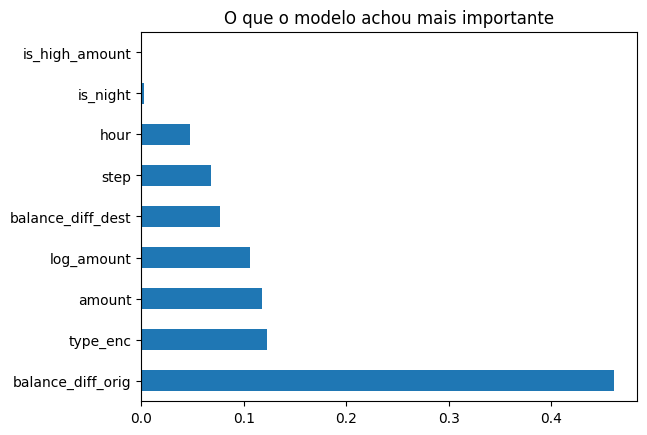

: 

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

importances = pd.Series(rf.feature_importances_, index=X.columns)
importances.nlargest(10).plot(kind='barh')
plt.title("O que o modelo achou mais importante")
plt.show()

# Plus

Verificando se escolhendo parametros a mao melhora em algo

In [ ]:
colunas_foco = ['is_night', 'balance_diff_dest', 'amount', 'step', 'balance_diff_orig', 'type_enc'] #selecionando as colunas mais importantes para o modelo Random Forest

rf_focado = RandomForestClassifier(
    n_estimators=50,
    max_depth=12,
   min_samples_leaf=100,
   class_weight='balanced', #usando class_weight para lidar com o desbalanceamento
   n_jobs=-1,
    random_state=42
)
rf_focado.fit(X_train[colunas_foco], y_train)

In [ ]:
from sklearn.metrics import roc_auc_score, average_precision_score

def evaluate_model(model, X, y):
    score = model.predict_proba(X)[:, 1] #obtendo as probabilidades de fraude para o conjunto de teste
    return{
        "ROC-AUC": roc_auc_score(y, score), #calculando a métrica ROC AUC para avaliar o desempenho do modelo
        "PR-AUC": average_precision_score(y, score) #calculando a métrica AUC-PRC para avaliar o desempenho do modelo em dados desbalanceados
    }

print("Avaliação do modelo Random Forest selecionado:", evaluate_model(rf_focado, X_test[colunas_foco], y_test))
print("Avaliação do modelo Random Forest normal:", evaluate_model(rf, X_test, y_test))

Avaliação do modelo Random Forest selecionado: {'ROC-AUC': 0.9972443150886187, 'PR-AUC': 0.8019068784108607}


Note que ele é um pouco pior que o normal, portanto a seleção não foi boa, ou todos os dados são necessários

In [ ]:
colunas_foco2 = ['hour', 'step', 'balance_diff_dest', 'log_amount', 'amount', 'balance_diff_orig', 'type_enc'] #selecionando as colunas mais importantes para o modelo Random Forest

rf_focado2 = RandomForestClassifier(
    n_estimators=50,
    max_depth=12,
   min_samples_leaf=100,
   class_weight='balanced', #usando class_weight para lidar com o desbalanceamento
   n_jobs=-1,
    random_state=42
)
rf_focado2.fit(X_train[colunas_foco2], y_train)

RandomForestClassifier(class_weight='balanced', max_depth=12,
                       min_samples_leaf=100, n_estimators=50, n_jobs=-1,
                       random_state=42)

In [ ]:
from sklearn.metrics import roc_auc_score, average_precision_score

def evaluate_model(model, X, y):
    score = model.predict_proba(X)[:, 1] #obtendo as probabilidades de fraude para o conjunto de teste
    return{
        "ROC-AUC": roc_auc_score(y, score), #calculando a métrica ROC AUC para avaliar o desempenho do modelo
        "PR-AUC": average_precision_score(y, score) #calculando a métrica AUC-PRC para avaliar o desempenho do modelo em dados desbalanceados
    }

# print("Avaliação do modelo Random Forest selecionado:", evaluate_model(rf_focado, X_test[colunas_foco], y_test))
print("Avaliação do modelo Random Forest normal:", evaluate_model(rf_focado2, X_test[colunas_foco2], y_test))

Avaliação do modelo Random Forest normal: {'ROC-AUC': 0.9976638294013863, 'PR-AUC': 0.8430142285584994}


Excluir is_night e is_high_amount melhora a analise

# Testing


In [42]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
import joblib




artifact = joblib.load('best_model_artifact.pkl')
model = artifact['model']
features = artifact['features']

y_scores = model.predict_proba(X_test)[:, 1] #obtendo as probabilidades de fraude para o conjunto de teste
precision, recall, thresholds = precision_recall_curve(y_test, y_scores) #calculando os valores de precisão, recall e os limiares para a curva de precisão-recall

#Achando o melhor threshold com recall >= 0.9 e melhor precisão
candidates = [
    (p, r, t) for p, r, t in zip(precision[:-1], recall[:-1], thresholds) 
    if (r >= 0.75)
]

best_threshold, best_recall, best_precision = max(candidates, key=lambda x: x[0]) #selecionando o threshold com a maior precisão entre os candidatos que têm recall >= 0.9

y_scores = model.predict_proba(X_test[features])[:, 1]
y_pred = (y_scores > best_threshold).astype(int)

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel() #extraindo os valores da matriz de confusão para calcular métricas como precisão, recall, etc.

sumary = pd.DataFrame({
    "Count": [tp, fn, fp, tn]
    }, index = [
        "Correctly Detected Frauds (TP)",
        "Missed Frauds (FN)",
        "False Positives (FP)",
        "Correctly Detected Legitimates (TN)"
])

print(sumary)

print(f"\nFraud recall: {tp / (tp + fn):.4f}") 
print(f"Fraud precision: {tp / (tp + fp):.4f}")

                                       Count
Correctly Detected Frauds (TP)          1443
Missed Frauds (FN)                       200
False Positives (FP)                    2252
Correctly Detected Legitimates (TN)  1268629

Fraud recall: 0.8783
Fraud precision: 0.3905
